<a href="https://colab.research.google.com/github/Future-Analyst/Tensorflow-Exercises-/blob/main/03_CNN_exercise_usign_cifar10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## base line cnn model

In [1]:
# Imports for self-containment
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, MaxPool2D, Conv2D
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.optimizers import SGD ,Adam
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Re-load the CIFAR-10 dataset to get fresh integer labels
(x_train_full, y_train_full), (x_test_full, y_test_full) = cifar10.load_data()

# Limit the dataset to 1000 samples for consistency with previous steps
x_train_model = x_train_full[:1000]
y_train_model = y_train_full[:1000]

x_test_model = x_test_full[:1000]
y_test_model = y_test_full[:1000]

# Normalize image data
x_train_model = x_train_model / 255.0
x_test_model = x_test_model / 255.0

# One-hot encode the labels correctly for CategoricalCrossentropy
# This converts labels from (num_samples, 1) integer format to (num_samples, num_classes) binary format
y_train_model = to_categorical(y_train_model, num_classes=10)
y_test_model = to_categorical(y_test_model, num_classes=10)



170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
# baseline model
model_0 = Sequential([
    Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    MaxPool2D(2),
    Conv2D(32, 3, activation='relu'),
    Conv2D(32, 3, activation='relu'),
    MaxPool2D(2),
    Flatten(),
    Dense(10, activation='softmax')
])

model_0.compile(
    loss=CategoricalCrossentropy(),
    optimizer=SGD(learning_rate=0.01),
    metrics=['accuracy']
)

model_0.fit(
    x_train_model,
    y_train_model,
    epochs=5,
    validation_data=(x_test_model, y_test_model)
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - accuracy: 0.1090 - loss: 2.3006 - val_accuracy: 0.0940 - val_loss: 2.3018
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.1180 - loss: 2.2961 - val_accuracy: 0.1040 - val_loss: 2.2984
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.1310 - loss: 2.2925 - val_accuracy: 0.0940 - val_loss: 2.2965
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.1220 - loss: 2.2889 - val_accuracy: 0.0980 - val_loss: 2.2934
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.1280 - loss: 2.2856 - val_accuracy: 0.1040 - val_loss: 2.2908


In [ ]:
# check the layers in our baseline model
model_0.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         8,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,404 (107.05 KB)

 Trainable params: 27,402 (107.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
# Evaluate the baseline model
model_0.evaluate(x_test_model, y_test_model)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.1040 - loss: 2.2908


[2.290771961212158, 0.10400000214576721]

In [ ]:
# Build a second model
import tensorflow as tf
tf.random.set_seed(42)

# Create a model to improve the baseline model

model_1 = Sequential([
    # Convolutional Base for feature extraction
    Conv2D(32, 3, activation='elu', input_shape=(32,32,3)),
    MaxPool2D(2),
    Conv2D(64, 3, activation='elu'), # Increased filters for more complex features
    MaxPool2D(2),
    Conv2D(128, 3, activation='elu'), # Added another convolutional layer

    # Flatten the output of the convolutional layers to feed into Dense layers
    Flatten(),

    # Dense layers for classification
    Dense(100, activation='elu'),
    Dense(100, activation='elu'),
    Dense(10, activation='softmax') # Output layer for 10 classes
])

# Compile the model
model_1.compile(loss = CategoricalCrossentropy(),
                optimizer=SGD(learning_rate=0.01),
                metrics=['accuracy'])

# Fit the model
model_1.fit(
    x_train_model,
    y_train_model,
    epochs=20,
    validation_data=(x_test_model, y_test_model),
    steps_per_epoch=len(x_train_model) // 32
)

Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.1320 - loss: 2.2929 - val_accuracy: 0.1200 - val_loss: 2.2799
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.1800 - loss: 2.2570 - val_accuracy: 0.1660 - val_loss: 2.2483
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.2090 - loss: 2.2162 - val_accuracy: 0.1920 - val_loss: 2.2077
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.2450 - loss: 2.1645 - val_accuracy: 0.2100 - val_loss: 2.1588
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step - accuracy: 0.2570 - loss: 2.1051 - val_accuracy: 0.2180 - val_loss: 2.1139
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.2810 - loss: 2.0507 - val_accuracy: 0.2360 - val_loss: 2.0808
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.2890 - loss: 2.0080 - val_accuracy: 0.2760 - val_loss: 2.0534
Epoch 8/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.3110 - loss: 1.9714 - val_accuracy: 0.2940 - 

In [ ]:
# Build a third model by just increasing the numer epochs to 50
import tensorflow as tf
tf.random.set_seed(42)

# Create a model to improve the baseline model

model_1 = Sequential([
    # Convolutional Base for feature extraction
    Conv2D(64, 3, activation='elu', input_shape=(32,32,3)),
    MaxPool2D(2),
    Conv2D(78, 3, activation='elu'), # Increased filters for more complex features
    MaxPool2D(2),
    Conv2D(158, 3, activation='elu'), # Added another convolutional layer

    # Flatten the output of the convolutional layers to feed into Dense layers
    Flatten(),

    # Dense layers for classification
    Dense(150, activation='elu'),
    Dense(150, activation='elu'),
    Dense(150, activation='elu'),
    Dense(150, activation='elu'),
    Dense(10, activation='softmax') # Output layer for 10 classes
])

# Compile the model
model_1.compile(loss = CategoricalCrossentropy(),
                optimizer=SGD(learning_rate=0.01),
                metrics=['accuracy'])

# Fit the model
model_1.fit(
    x_train_model,
    y_train_model,
    epochs=50,
    validation_data=(x_test_model, y_test_model),
    steps_per_epoch=len(x_train_model) // 62
)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 228ms/step - accuracy: 0.1190 - loss: 2.3037 - val_accuracy: 0.0840 - val_loss: 2.2913
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 206ms/step - accuracy: 0.1430 - loss: 2.2782 - val_accuracy: 0.1050 - val_loss: 2.2733
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 255ms/step - accuracy: 0.1650 - loss: 2.2557 - val_accuracy: 0.1410 - val_loss: 2.2525
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 278ms/step - accuracy: 0.1870 - loss: 2.2304 - val_accuracy: 0.1850 - val_loss: 2.2280
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 245ms/step - accuracy: 0.2100 - loss: 2.2007 - val_accuracy: 0.2240 - val_loss: 2.1993
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 245ms/step - accuracy: 0.2370 - loss: 2.1664 - val_accuracy: 0.2430 - val_loss: 2.1675
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 261ms/step - accuracy: 0.2500 - loss: 2.1294 - val_accuracy: 0.2430 - val_loss: 2.1366
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 204ms/step - accuracy: 0.2650 - loss: 2.0931 - val_accuracy: 0.

In [ ]:
# Evaluate the 3rd model
model_1.evaluate(x_test_model, y_test_model)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.3840 - loss: 1.7378


[1.7378102540969849, 0.3840000033378601]

In [ ]:
# #rd model summary
model_1.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 78)     │        45,006 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 78)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 4, 4, 158)      │       111,074 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2528)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 150)            │       379,350 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 150)            │        22,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 150)            │        22,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 150)            │        22,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 606,684 (2.31 MB)

 Trainable params: 606,682 (2.31 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [8]:
## Building the  4th model using data augmentation this time
from tensorflow.keras import layers
# Data Augmentation
data_augmentation = Sequential([
    layers.RandomFlip("horinzontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.1)
    ])

# Normalization (Transfromation)
normalization_layer = layers.Rescaling(1./255)

In [9]:
# buildin the fourth model using augmentation

# Build the sequential Api
model_4 = Sequential([
    data_augmentation, # augmentation happens here

    # Convolutional Base for feature extraction
    Conv2D(64, 3, activation='gelu', input_shape=(32,32,3)),
    MaxPool2D(2),
    Conv2D(78, 3, activation='gelu'), # Increased filters for more complex features
    MaxPool2D(2),
    Conv2D(200, 3, activation='gelu'), # Added another convolutional layer

    # Flatten the output of the convolutional layers to feed into Dense layers
    Flatten(),

    # Dense layers for classification
    Dense(170, activation='gelu'),
    Dense(170, activation='gelu'),
    Dense(170, activation='gelu'),
    Dense(170, activation='gelu'),
    Dense(10, activation='softmax') # Output layer for 10 classes, using softmax for multi-class classification
    ])

# Compile the model
model_4.compile(
    optimizer = Adam(learning_rate=0.003),
    loss = CategoricalCrossentropy(), # Changed to CategoricalCrossentropy for one-hot encoded labels
    metrics = ["accuracy"]
)

# fit the model
history_4 = model_4.fit(
    x_train_model,
    y_train_model,
    epochs=50,
    validation_data=(x_test_model, y_test_model),
    steps_per_epoch=len(x_train_model) // 62,
    verbose = 1
)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 490ms/step - accuracy: 0.1130 - loss: 2.3184 - val_accuracy: 0.0980 - val_loss: 2.3052
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 397ms/step - accuracy: 0.1110 - loss: 2.3319 - val_accuracy: 0.1040 - val_loss: 2.2995
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 438ms/step - accuracy: 0.1350 - loss: 2.2792 - val_accuracy: 0.1310 - val_loss: 2.2737
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 397ms/step - accuracy: 0.1820 - loss: 2.1630 - val_accuracy: 0.2140 - val_loss: 2.0762
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 308ms/step - accuracy: 0.2200 - loss: 2.0769 - val_accuracy: 0.1800 - val_loss: 2.1784
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 392ms/step - accuracy: 0.2050 - loss: 2.0476 - val_accuracy: 0.1880 - val_loss: 2.1988
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 309ms/step - accuracy: 0.2290 - loss: 2.0222 - val_accuracy: 0.2410 - val_loss: 2.0280
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 393ms/step - accuracy: 0.2810 - loss: 1.9309 - val_accuracy: 0

In [11]:
# Evaluate the model_4

val_evaluation = model_4.evaluate(x_test_model, y_test_model)
train_evaluation = model_4.evaluate(x_train_model, y_train_model)

print("validation scores : ", val_evaluation)
print("training scores : ", train_evaluation)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.4130 - loss: 2.8973
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.9010 - loss: 0.3104
validation scores :  [2.8972513675689697, 0.4129999876022339]
training scores :  [0.31037795543670654, 0.9010000228881836]


<Axes: >

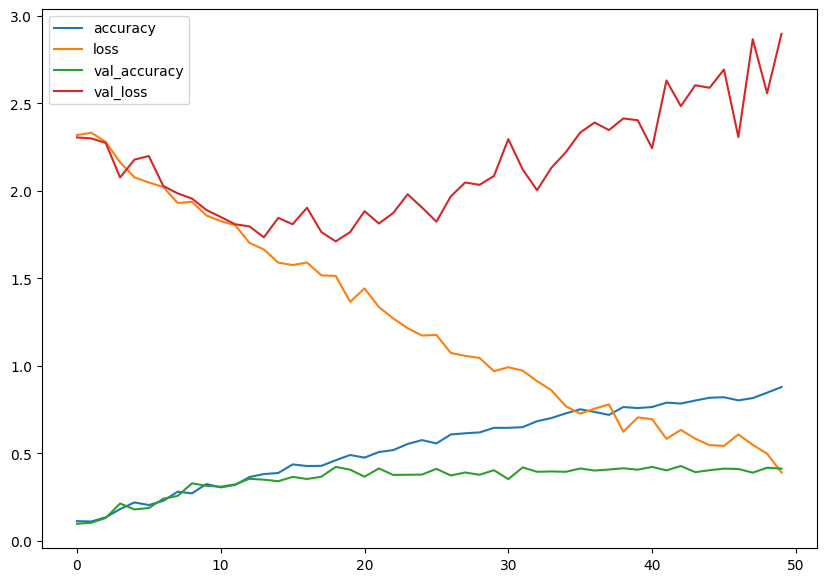

In [13]:
# Plot the training curves
import pandas as pd
pd.DataFrame(history_4.history).plot(figsize=(10,7))

In [16]:
# Plot the validation and training data separately
import matplotlib.pyplot as plt
def plot_loss_curves(history):
  """
  Return seperate loss curve for training and validation metrics.
  """
  loss = history.history["loss"]
  val_loss = history.history["val_loss"]

  accuracy = history.history["accuracy"]
  val_accuracy = history.history["val_accuracy"]

  epochs = range(len(history.history["loss"]))

  # Plot loss
  plt.plot(epochs, loss, label="training_loss")
  plt.plot(epochs, val_loss, label="val_loss")

  # Plot accuracy
  plt.figure()
  plt.plot(epochs, accuracy, label= "training_accuracy")
  plt.plot(epochs, val_accuracy, label = "val_accuracy")
  plt.title("Accuracy")
  plt.xlabel("Epochs") # Added xlabel
  plt.legend();

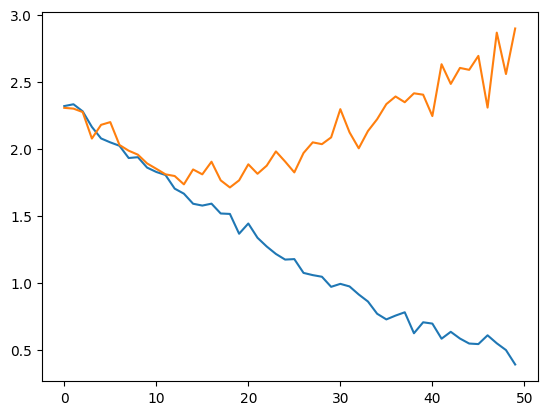

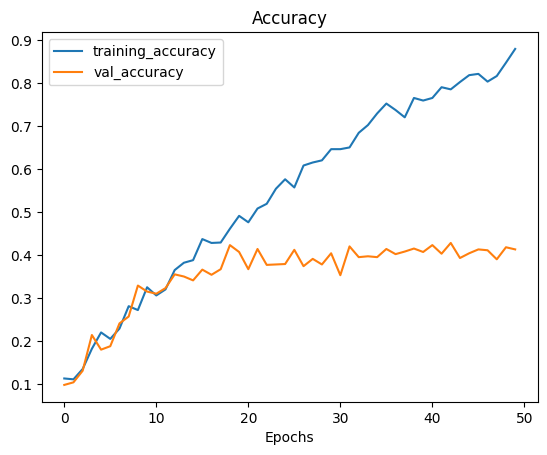

In [17]:
# Check out the loss Curve of model_4
plot_loss_curves(history_4)

In [24]:
# Lets reduce the complexity of the model
# first lets import importtant modules we are to apply

# import the earlystopping callbacks
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import BatchNormalization, Dropout
# Import regularizers
from tensorflow.keras.regularizers import l2

In [30]:
# Build Model 5

model_5 = Sequential([
    data_augmentation,

    Conv2D( 32, (3,3), padding='same',activation = 'gelu',
           kernel_regularizer = l2(0.001), input_shape=(32,32,3)
           ),

    Conv2D( 64, (3,3), padding='same', activation='gelu',
           kernel_regularizer=l2(0.001)
        ),

    BatchNormalization(),
    MaxPool2D(pool_size=(2,2)
    ),

    Conv2D(
        128, (3,3), activation="gelu", kernel_regularizer=l2(0.001)
    ),

    Flatten(),

    Dense(128, activation="gelu", kernel_regularizer = l2(0.001)
    ),

    Dropout(0.5),

    #outpy layer
    Dense(10, activation='softmax')
])

# Compile the model
model_5.compile(
    optimizer = Adam(learning_rate=0.001),
    loss = CategoricalCrossentropy(),
    metrics = ["accuracy"]
)
# Build the callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights = True
)

# Train Model
history_5= model_5.fit(
    x_train_model,
    y_train_model,
    epochs=5,
    validation_data=(x_test_model, y_test_model),
    callbacks=[early_stop],
)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 418ms/step - accuracy: 0.2110 - loss: 2.8081 - val_accuracy: 0.1590 - val_loss: 2.7555
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 422ms/step - accuracy: 0.2600 - loss: 2.4892 - val_accuracy: 0.1220 - val_loss: 2.8021
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 469ms/step - accuracy: 0.3050 - loss: 2.3921 - val_accuracy: 0.1570 - val_loss: 2.8048
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 482ms/step - accuracy: 0.3340 - loss: 2.3500 - val_accuracy: 0.1070 - val_loss: 2.8904
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 446ms/step - accuracy: 0.3340 - loss: 2.2837 - val_accuracy: 0.1650 - val_loss: 2.8953


In [31]:
# Evaluate the training and testing scores
print("the training score : ", model_5.evaluate(x_train_model, y_train_model))
print("the testing score : ", model_5.evaluate(x_test_model, y_test_model))

32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 119ms/step - accuracy: 0.2030 - loss: 2.7502
the training score :  [2.750166893005371, 0.2029999941587448]
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - accuracy: 0.1590 - loss: 2.7555
the testing score :  [2.7554755210876465, 0.1589999943971634]


<Axes: >

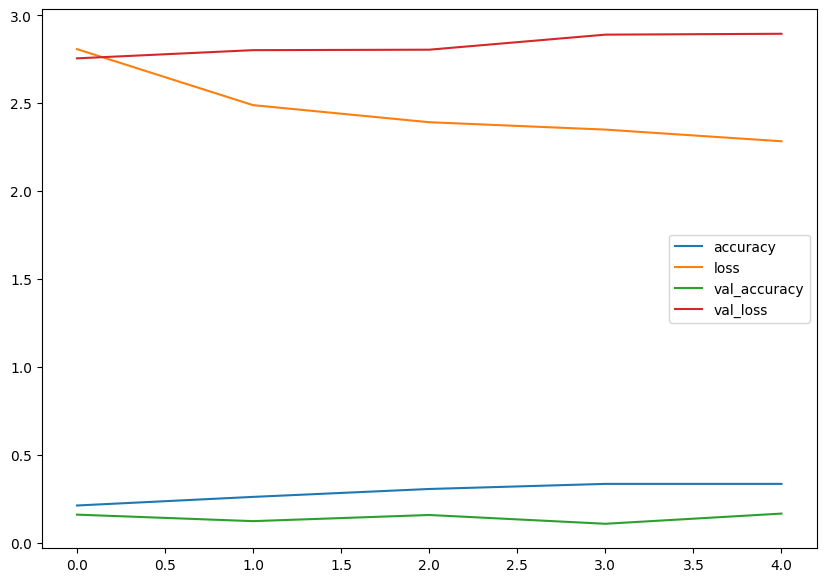

In [33]:
# lets plot the training loss curves
pd.DataFrame(history_5.history).plot(figsize=(10,7))

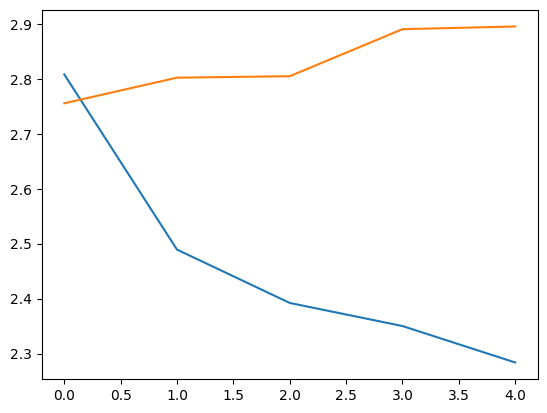

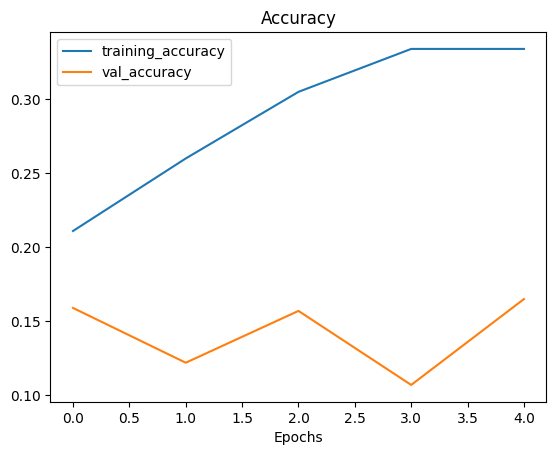

In [35]:
plot_loss_curves(history_5)